# KneeVision++ — Full Pipeline

Explainable multimodal AI for knee OA severity grading.

**Phases covered:**
1. Setup & Data Exploration
2. Model Training (DenseNet121 & EfficientNet-B4)
3. Model Comparison
4. Ensemble Evaluation (Cohen's Kappa, Confusion Matrix)
5. Explainable AI (Grad-CAM, Score-CAM, LIME)
6. Test-Time Augmentation

In [1]:
# --- Setup & imports ---
import sys, os
from pathlib import Path

# Detect Colab vs local
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    # Adjust this path to where you placed the project
    PROJECT_ROOT = Path("/content/drive/MyDrive/KneeVision")
    !pip install torch torchvision numpy pillow tqdm scikit-learn matplotlib -q
else:
    PROJECT_ROOT = Path.cwd().parent
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "matplotlib", "scikit-learn", "-q"], capture_output=True)

sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)
print(f"Project root: {PROJECT_ROOT}")
print(f"Working dir:  {os.getcwd()}")

Project root: /home/darshan/learning/ai/KneeVision
Working dir:  /home/darshan/learning/ai/KneeVision


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
from tqdm import tqdm

%load_ext autoreload
%autoreload 2

from kneevision.config.settings import RAW_DATA_DIR, BATCH_SIZE, LEARNING_RATE, NUM_EPOCHS
from kneevision.models.image_model import KneeXRayClassifier
from kneevision.data.dataset import KneeXRayDataset, make_weighted_sampler
from kneevision.data.transforms import train_transform, minority_transform, val_transform, tta_transforms_list
from kneevision.training.trainer import train_epoch, validate
from kneevision.training.losses import FocalLoss, OrdinalLoss, ordinal_to_class
from kneevision.utils.helpers import set_seed, get_device
from kneevision.evaluation.tta import tta_predict
from kneevision.xai import gradcam, scorecam, lime

set_seed(42)
device = get_device()
IS_CUDA = device.type == "cuda"

print(f"PyTorch: {torch.__version__}")
print(f"Device:  {device}")
if IS_CUDA:
    print(f"GPU:     {torch.cuda.get_device_name(0)}")
    print(f"Memory:  {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GiB")
    print(f"CC:      {torch.cuda.get_device_capability(0)}")
    torch.cuda.empty_cache()
else:
    print("WARNING: No GPU detected — training will be slow on CPU.")
print(f"Data:    {RAW_DATA_DIR} (exists: {RAW_DATA_DIR.exists()})")

PyTorch: 2.13.0+cu130
Device:  cuda
GPU:     NVIDIA GeForce RTX 4050 Laptop GPU
Memory:  5.7 GiB
CC:      (8, 9)
Data:    /home/darshan/learning/ai/KneeVision/data/raw (exists: True)


---
## 1. Data Exploration

Train: 5778 images
Val:   826 images
Test:  1656 images


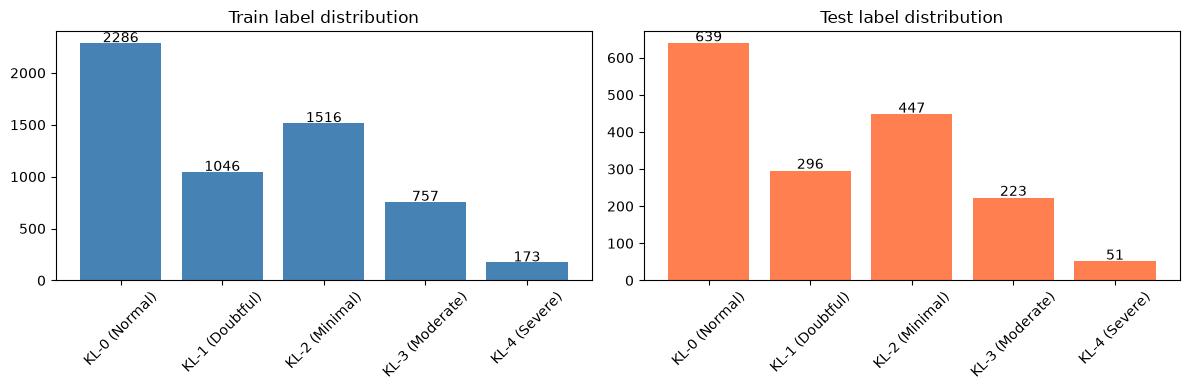

In [3]:
# --- Load dataset paths ---
def get_paths_and_labels(split: str):
    paths, labels = [], []
    split_dir = RAW_DATA_DIR / split
    if not split_dir.exists():
        raise FileNotFoundError(f"Data not found at {split_dir}")
    for grade_dir in sorted(split_dir.iterdir()):
        if not grade_dir.is_dir():
            continue
        label = int(grade_dir.name)
        for img_path in sorted(grade_dir.glob("*.png")):
            paths.append(img_path)
            labels.append(label)
    return paths, labels

train_paths, train_labels = get_paths_and_labels("train")
val_paths,   val_labels   = get_paths_and_labels("val")
test_paths,  test_labels  = get_paths_and_labels("test")

print(f"Train: {len(train_paths)} images")
print(f"Val:   {len(val_paths)} images")
print(f"Test:  {len(test_paths)} images")

# Label distribution
kl_names = ["KL-0 (Normal)", "KL-1 (Doubtful)", "KL-2 (Minimal)", "KL-3 (Moderate)", "KL-4 (Severe)"]
train_dist = [train_labels.count(i) for i in range(5)]
test_dist  = [test_labels.count(i) for i in range(5)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(kl_names, train_dist, color="steelblue")
ax1.set_title("Train label distribution")
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(train_dist):
    ax1.text(i, v + 10, str(v), ha='center')

ax2.bar(kl_names, test_dist, color="coral")
ax2.set_title("Test label distribution")
ax2.tick_params(axis='x', rotation=45)
for i, v in enumerate(test_dist):
    ax2.text(i, v + 5, str(v), ha='center')
plt.tight_layout()
plt.show()

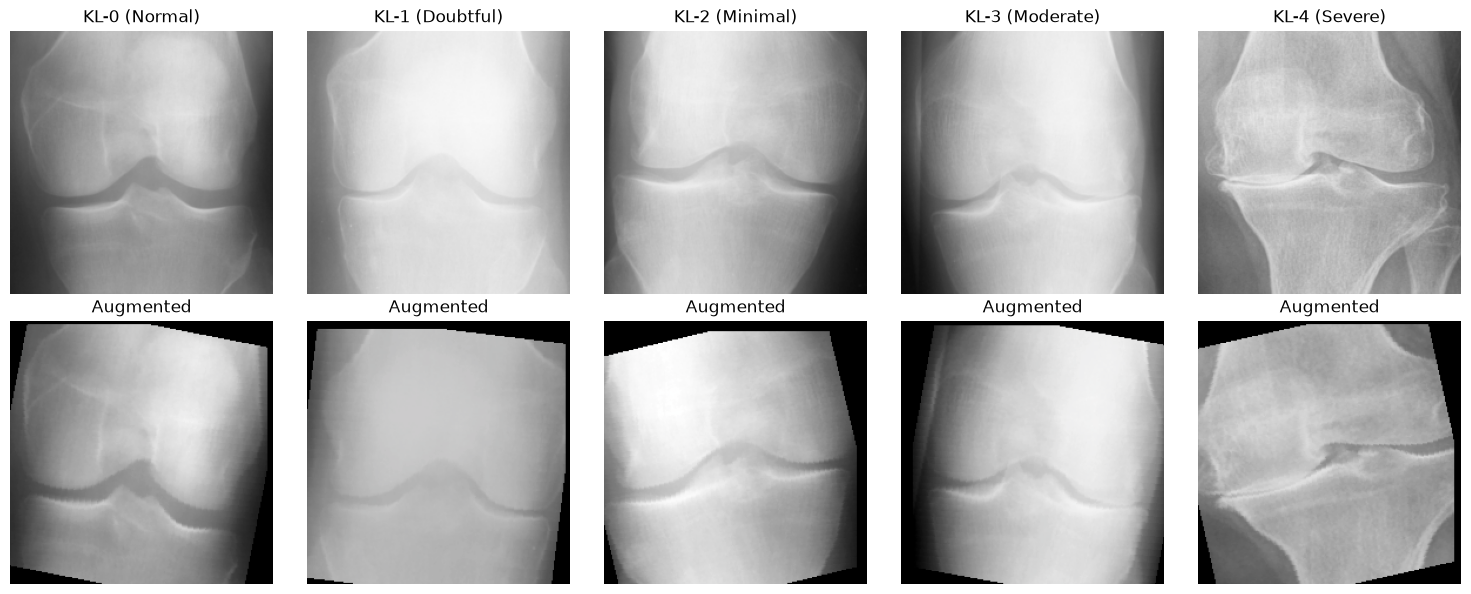

In [4]:
# Visualize a few X-ray samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for grade in range(5):
    idx = train_labels.index(grade)
    img = Image.open(train_paths[idx]).convert("RGB")
    axes[0, grade].imshow(img, cmap="gray")
    axes[0, grade].set_title(f"{kl_names[grade]}")
    axes[0, grade].axis("off")
    # Also show with augmentation
    aug = train_transform(img)
    aug_np = aug.permute(1, 2, 0).numpy()
    # Undo normalize for display
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    aug_np = np.clip(aug_np * std + mean, 0, 1)
    axes[1, grade].imshow(aug_np)
    axes[1, grade].set_title("Augmented")
    axes[1, grade].axis("off")
plt.tight_layout()
plt.show()

---
## 2. Training

In [5]:
# Create DataLoaders (pin_memory speeds up GPU transfer)
# Minority classes (KL-3, KL-4) get stronger augmentation
train_ds = KneeXRayDataset(train_paths, train_labels, train_transform,
                           minority_transform=minority_transform, minority_labels={3, 4})
val_ds   = KneeXRayDataset(val_paths,   val_labels,   val_transform)

# WeightedRandomSampler balances each batch so minority classes appear more often
sampler = make_weighted_sampler(train_labels)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=IS_CUDA)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=IS_CUDA)

In [6]:
# Class weights for handling imbalance
class_counts = torch.tensor([train_labels.count(i) for i in range(5)], dtype=torch.float)
class_weights = (1.0 / class_counts) * class_counts.sum() / 5
print(f"Class counts: {class_counts.tolist()}")
print(f"Class weights: {class_weights.tolist()}")

Class counts: [2286.0, 1046.0, 1516.0, 757.0, 173.0]
Class weights: [0.5055118203163147, 1.1047800779342651, 0.762269139289856, 1.5265522003173828, 6.6797685623168945]


In [7]:
def train_model(model_name: str, use_focal: bool = True, num_epochs: int = NUM_EPOCHS, ordinal: bool = False):
    mode = "Ordinal" if ordinal else "FocalLoss" if use_focal else "CrossEntropy"
    print(f"\n{'='*60}")
    print(f"Training: {model_name}  |  {mode}")
    print(f"{'='*60}")

    model = KneeXRayClassifier(model_name, 5, ordinal=ordinal).to(device)
    params = sum(p.numel() for p in model.parameters())
    print(f"Parameters: {params:,}")
    print(f"Output size: {model.classifier[-1].out_features} ({'ordinal thresholds' if ordinal else 'class logits'})")

    if ordinal:
        criterion = OrdinalLoss(num_classes=5)
    elif use_focal:
        criterion = FocalLoss(alpha=class_weights.to(device), gamma=2.0, label_smoothing=0.1)
    else:
        criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    scaler = torch.amp.GradScaler("cuda") if IS_CUDA else None

    save_dir = PROJECT_ROOT / "models"
    save_dir.mkdir(exist_ok=True)
    suffix = "_ordinal" if ordinal else ""

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_acc = 0.0

    @torch.inference_mode()
    def validate_ordinal(model, loader):
        model.eval()
        total_loss = 0.0
        correct = 0
        total = 0
        for images, labels in loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            logits = model(images)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            preds = ordinal_to_class(logits)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
        return total_loss / len(loader), correct / total

    for epoch in range(1, num_epochs + 1):
        # --- Training with AMP ---
        model.train()
        total_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch}"):
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            optimizer.zero_grad()
            if scaler:
                with torch.amp.autocast("cuda"):
                    loss = criterion(model(images), labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss = criterion(model(images), labels)
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
        train_loss = total_loss / len(train_loader)

        # --- Validation ---
        if ordinal:
            val_loss, val_acc = validate_ordinal(model, val_loader)
        else:
            val_loss, val_acc = validate(model, val_loader, criterion, device)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        mem = f" | GPU mem: {torch.cuda.max_memory_allocated()/1024**3:.2f} GiB" if IS_CUDA else ""
        print(f"Epoch {epoch:2d}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}{mem}")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), save_dir / f"best_{model_name}{suffix}.pt")
            print(f"  -> Saved best model (acc={val_acc:.4f})")
        if IS_CUDA:
            torch.cuda.reset_peak_memory_stats()

    print(f"Finished {model_name} | Best val acc: {best_acc:.4f}")
    return model, history, best_acc, params

In [16]:
# Train both models (set num_epochs to a small value for quick testing, e.g. 3)
# For full training, use NUM_EPOCHS (50)
N_EPOCHS = 20 # Change to NUM_EPOCHS for full training

results = {}
for name in ["densenet121"]:
    model, history, best_acc, params = train_model(name, use_focal=True, num_epochs=N_EPOCHS,ordinal=True)
    results[name] = {"model": model, "history": history, "best_acc": best_acc, "params": params}


Training: densenet121  |  Ordinal
Parameters: 7,480,708
Output size: 4 (ordinal thresholds)


Epoch 1: 100%|██████████| 181/181 [01:00<00:00,  2.99it/s]


Epoch  1/20 | Train Loss: 0.3596 | Val Loss: 0.4016 | Val Acc: 0.4455 | GPU mem: 2.57 GiB
  -> Saved best model (acc=0.4455)


Epoch 2: 100%|██████████| 181/181 [01:04<00:00,  2.81it/s]


Epoch  2/20 | Train Loss: 0.2583 | Val Loss: 0.4285 | Val Acc: 0.4552 | GPU mem: 2.57 GiB
  -> Saved best model (acc=0.4552)


...

Epoch 18/20 | Train Loss: 0.1403 | Val Loss: 0.3793 | Val Acc: 0.5508 | GPU mem: 2.57 GiB


Epoch 19: 100%|██████████| 181/181 [01:04<00:00,  2.81it/s]


Epoch 19/20 | Train Loss: 0.1427 | Val Loss: 0.3843 | Val Acc: 0.5508 | GPU mem: 2.57 GiB


Epoch 20: 100%|██████████| 181/181 [01:04<00:00,  2.80it/s]


Epoch 20/20 | Train Loss: 0.1404 | Val Loss: 0.3712 | Val Acc: 0.5508 | GPU mem: 2.57 GiB
Finished densenet121 | Best val acc: 0.5920


---
## 3. Training Curves

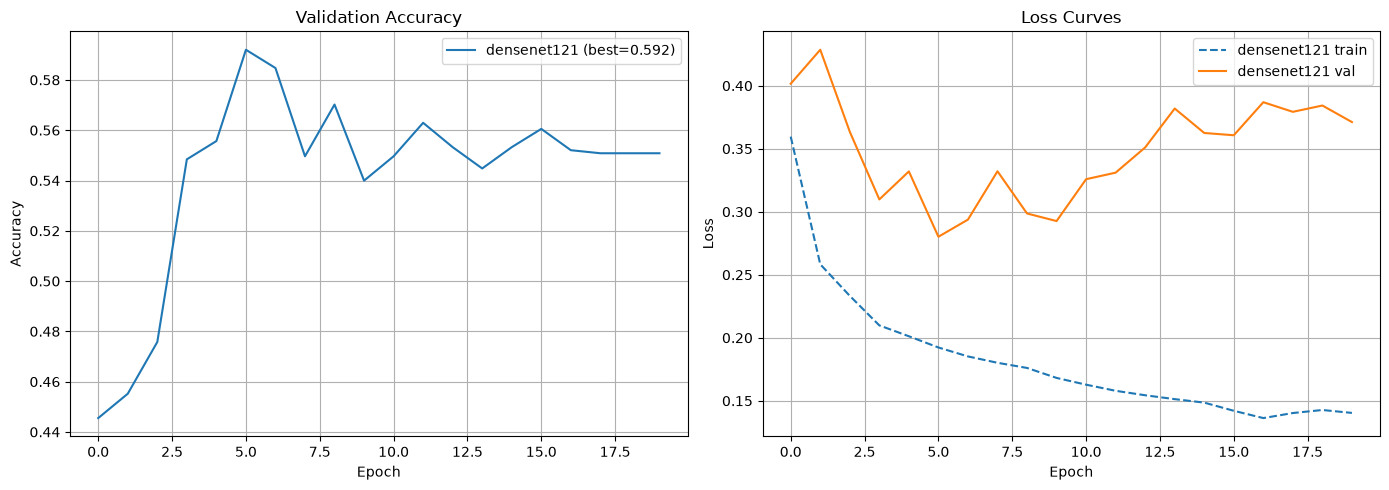


Model                |     Params |   Best Acc
------------------------------------------------
densenet121          |  7,480,708 |     0.5920


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in results.items():
    h = res["history"]
    axes[0].plot(h["val_acc"], label=f"{name} (best={res['best_acc']:.3f})")
    axes[1].plot(h["train_loss"], "--", label=f"{name} train")
    axes[1].plot(h["val_loss"], "-", label=f"{name} val")

axes[0].set_title("Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("Loss Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Comparison table
print(f"\n{'Model':<20} | {'Params':>10} | {'Best Acc':>10}")
print("-" * 48)
for name, res in results.items():
    print(f"{name:<20} | {res['params']:>10,} | {res['best_acc']:>10.4f}")

---
## 4. Ensemble Evaluation on Test Set

In [18]:
# Load best saved models for ensemble evaluation
test_ds = KneeXRayDataset(test_paths, test_labels, val_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=IS_CUDA)
print(f"Test samples: {len(test_ds)}")

Test samples: 1656


In [19]:
@torch.inference_mode()
def ensemble_predict(models, loader, device):
    all_preds, all_labels, all_probs = [], [], []
    for images, labels in tqdm(loader, desc="Ensemble"):
        images = images.to(device)
        probs = torch.zeros(len(images), 5, device=device)
        for model in models:
            model.eval()
            probs += F.softmax(model(images), dim=1)
        probs /= len(models)
        all_preds.extend(probs.argmax(dim=1).cpu().tolist())
        all_labels.extend(labels.tolist())
        all_probs.extend(probs.cpu().numpy())
    return all_preds, all_labels, np.array(all_probs)

# Load models from saved checkpoints if they exist, otherwise use in-memory
ensemble_models = []
for name in ["densenet121", "efficientnet-b4"]:
    path = Path(f"models/best_{name}.pt")
    if path.exists():
        m = KneeXRayClassifier(name, 5).to(device)
        m.load_state_dict(torch.load(path, map_location=device, weights_only=True))
        ensemble_models.append(m)
        print(f"Loaded {name} from {path}")
    elif name in results:
        ensemble_models.append(results[name]["model"])
        print(f"Using in-memory {name}")
    else:
        print(f"Warning: {name} not available")

if ensemble_models:
    preds, labels, probs = ensemble_predict(ensemble_models, test_loader, device)

Loaded densenet121 from models/best_densenet121.pt
Loaded efficientnet-b4 from models/best_efficientnet-b4.pt


Ensemble: 100%|██████████| 52/52 [00:25<00:00,  2.04it/s]



CLASSIFICATION REPORT
                 precision    recall  f1-score   support

  KL-0 (Normal)     0.8255    0.6072    0.6997       639
KL-1 (Doubtful)     0.2668    0.6824    0.3837       296
 KL-2 (Minimal)     0.6509    0.2461    0.3571       447
KL-3 (Moderate)     0.6718    0.5874    0.6268       223
  KL-4 (Severe)     0.7692    0.9804    0.8621        51

       accuracy                         0.5320      1656
      macro avg     0.6369    0.6207    0.5859      1656
   weighted avg     0.6561    0.5320    0.5459      1656


Cohen's Kappa (quadratic): 0.7668

Confusion Matrix:
          KL-      0KL-      1KL-      2KL-      3KL-      4
Actual KL-   0     388     247       1       3       0
Actual KL-   1      67     202      20       7       0
Actual KL-   2      15     266     110      53       3
Actual KL-   3       0      42      38     131      12
Actual KL-   4       0       0       0       1      50


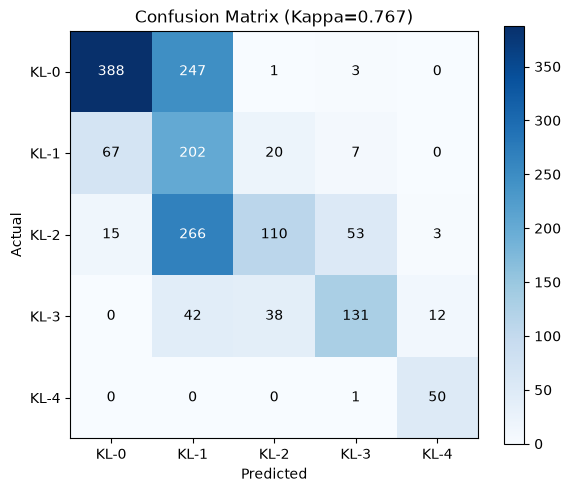

In [20]:
if ensemble_models:
    print("\n" + "="*65)
    print("CLASSIFICATION REPORT")
    print("="*65)
    print(classification_report(labels, preds, target_names=kl_names, digits=4))

    kappa = cohen_kappa_score(labels, preds, weights='quadratic')
    print(f"\nCohen's Kappa (quadratic): {kappa:.4f}")

    cm = confusion_matrix(labels, preds)
    print("\nConfusion Matrix:")
    print(f"{'':>10}", end="")
    for i in range(5):
        print(f"KL-{i:>7}", end="")
    print()
    for i in range(5):
        print(f"Actual KL-{i:>4}", end="")
        for j in range(5):
            print(f"{cm[i,j]:>8}", end="")
        print()

    # Confusion matrix heatmap
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticklabels([f"KL-{i}" for i in range(5)])
    ax.set_yticklabels([f"KL-{i}" for i in range(5)])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    for i in range(5):
        for j in range(5):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black")
    plt.colorbar(im)
    plt.title(f"Confusion Matrix (Kappa={kappa:.3f})")
    plt.tight_layout()
    plt.show()
else:
    print("No models available for evaluation.")

---
## 5. Explainable AI (XAI)

In [21]:
# Pick a sample from each KL grade for visualization
def get_sample_by_grade(paths, labels, grade):
    idx = labels.index(grade)
    return Image.open(paths[idx]).convert("RGB"), labels[idx]

samples = [get_sample_by_grade(test_paths, test_labels, g) for g in range(5)]

# Use the first trained model for XAI
xai_model_name = list(results.keys())[0]
xai_model = results[xai_model_name]["model"]
print(f"Using {xai_model_name} for explanations")

Using densenet121 for explanations


/home/darshan/learning/ai/KneeVision/.venv/lib/python3.14/site-packages/torch/nn/modules/module.py:1869: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


IndexError: invalid index to scalar variable.

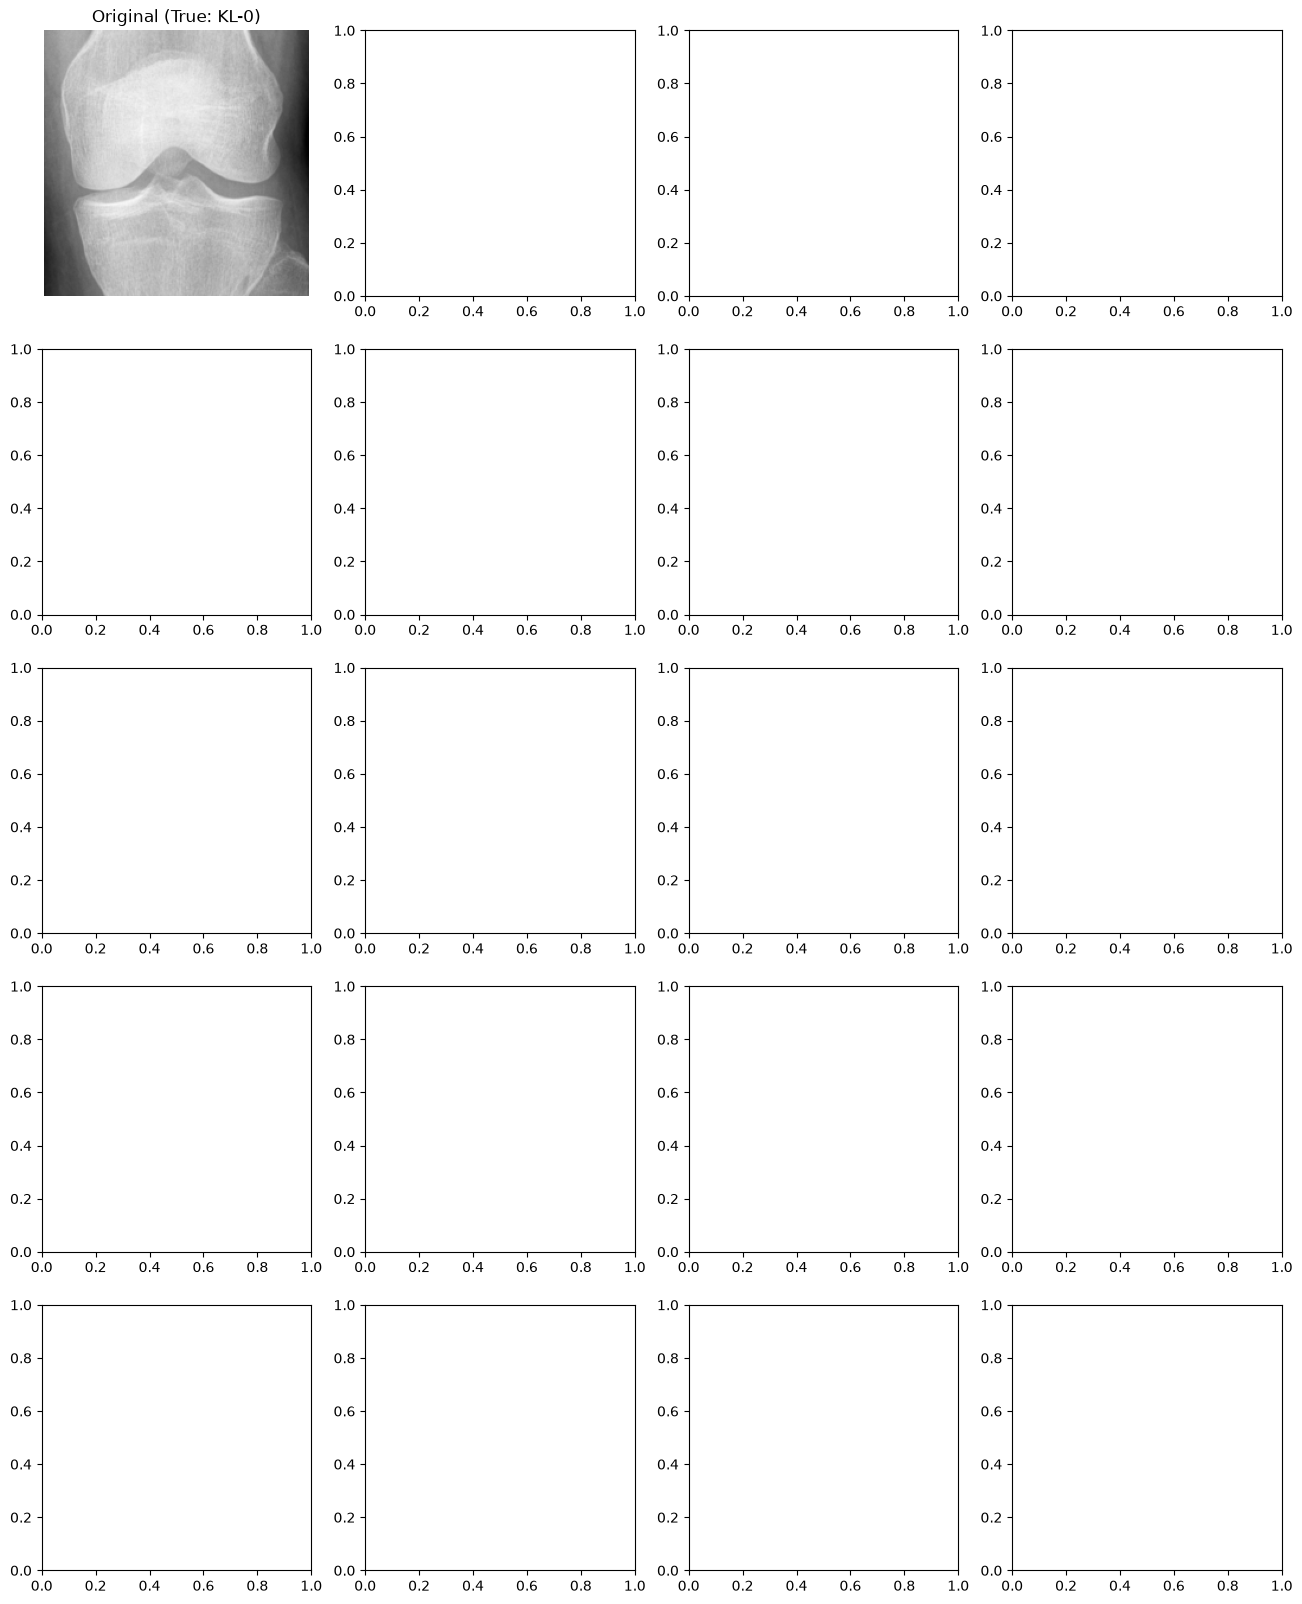

In [14]:
# Generate Grad-CAM, Score-CAM, and LIME explanations
fig, axes = plt.subplots(5, 4, figsize=(16, 20))

for row, (img, true_label) in enumerate(samples):
    # Original
    axes[row, 0].imshow(img, cmap="gray")
    axes[row, 0].set_title(f"Original (True: KL-{true_label})")
    axes[row, 0].axis("off")

    # Grad-CAM
    pred_gc, conf_gc, overlay_gc = gradcam.explain(xai_model, img, val_transform, device)
    axes[row, 1].imshow(overlay_gc)
    axes[row, 1].set_title(f"Grad-CAM\nPred: KL-{pred_gc} | {conf_gc:.2%}")
    axes[row, 1].axis("off")

    # Score-CAM
    pred_sc, conf_sc, overlay_sc = scorecam.explain(xai_model, img, val_transform, device)
    axes[row, 2].imshow(overlay_sc)
    axes[row, 2].set_title(f"Score-CAM\nPred: KL-{pred_sc} | {conf_sc:.2%}")
    axes[row, 2].axis("off")

    # LIME
    pred_li, conf_li, importance, segments = lime.explain(xai_model, img, val_transform, device)
    axes[row, 3].imshow(importance, cmap="Reds", alpha=0.7)
    axes[row, 3].imshow(np.array(img.resize((224, 224))) / 255.0, alpha=0.3)
    axes[row, 3].set_title(f"LIME\nPred: KL-{pred_li} | {conf_li:.2%}")
    axes[row, 3].axis("off")

plt.tight_layout()
plt.show()

---
## 6. Test-Time Augmentation (TTA)

In [ ]:
# Compare standard vs TTA prediction on a single image
img, true_label = get_sample_by_grade(test_paths, test_labels, 2)

# Standard prediction
x = val_transform(img).unsqueeze(0).to(device)
with torch.inference_mode():
    logits = xai_model(x)
    probs = F.softmax(logits, dim=1)
    std_pred = probs.argmax(dim=1).item()
    std_conf = probs[0, std_pred].item()

# TTA prediction
tta_pred, tta_conf = tta_predict(xai_model, img, device)

print(f"True label: KL-{true_label}")
print(f"Standard  -> KL-{std_pred}  (confidence: {std_conf:.2%})")
print(f"TTA       -> KL-{tta_pred}  (confidence: {tta_conf:.2%})")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].bar(range(5), probs.squeeze().cpu().numpy(), color="steelblue")
axes[0].set_xticks(range(5))
axes[0].set_xticklabels([f"KL-{i}" for i in range(5)])
axes[0].set_title(f"Standard Pred: KL-{std_pred}")
axes[0].set_ylabel("Probability")

# Get TTA probabilities
tta_probs = torch.zeros(5, device=device)
for tta_tfm in tta_transforms_list:
    x_tta = tta_tfm(img).unsqueeze(0).to(device)
    with torch.inference_mode():
        tta_probs += F.softmax(xai_model(x_tta), dim=1).squeeze()
tta_probs /= len(tta_transforms_list)

axes[1].bar(range(5), tta_probs.cpu().numpy(), color="coral")
axes[1].set_xticks(range(5))
axes[1].set_xticklabels([f"KL-{i}" for i in range(5)])
axes[1].set_title(f"TTA Pred: KL-{tta_pred}")
axes[1].set_ylabel("Probability")
plt.tight_layout()
plt.show()

RuntimeError: The size of tensor a (5) must match the size of tensor b (4) at non-singleton dimension 0

: 

---
## 7. Per-Class Performance Analysis

/home/darshan/learning/ai/KneeVision/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/darshan/learning/ai/KneeVision/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/darshan/learning/ai/KneeVision/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

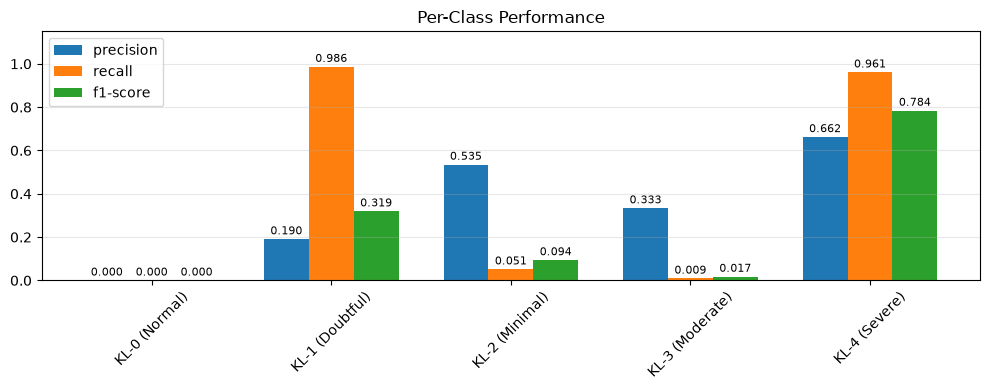

In [ ]:
if ensemble_models:
    report = classification_report(labels, preds, target_names=kl_names, digits=4, output_dict=True)

    metrics = ["precision", "recall", "f1-score"]
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(kl_names))
    width = 0.25
    for i, metric in enumerate(metrics):
        values = [report[kl][metric] for kl in kl_names]
        bars = ax.bar(x + i * width, values, width, label=metric)
        for bar, v in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{v:.3f}",
                    ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x + width)
    ax.set_xticklabels(kl_names, rotation=45)
    ax.set_ylim(0, 1.15)
    ax.legend()
    ax.set_title("Per-Class Performance")
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No predictions to analyze.")

---
## 8. Using a Custom Dataset

You can use any knee X-ray dataset. Supported formats:

### Format 1: Folder-based (current)
```
data/raw/
  train/
    0/  img1.png
    1/  img2.png
    2/  ...
    3/
    4/
  val/    (same structure)
  test/   (same structure)
```

### Format 2: CSV-based (flexible)
Create a CSV with columns: `filename,label,split`
```
filename,label,split
img_001.png,0,train
img_002.png,2,train
img_003.png,4,test
```

### OAI Dataset
Download from [nda.nih.gov/oai](https://nda.nih.gov/oai) (requires registration).
Place X-ray images in `data/raw/` then run the cell below to prepare.

In [ ]:
# --- Load any dataset ---
# Option A: Folder-based (default)
from kneevision.data.prepare import prepare_from_folders, print_split_summary

splits = prepare_from_folders(RAW_DATA_DIR)
print_split_summary(splits)
train_paths, train_labels = splits["train"]
val_paths,   val_labels   = splits.get("val", ([], []))
test_paths,  test_labels  = splits.get("test", ([], []))

# Option B: CSV-based (uncomment and adjust)
# from kneevision.data.prepare import prepare_from_csv
# splits = prepare_from_csv(Path("data/labels.csv"), RAW_DATA_DIR)
# ...

# Option C: Custom data — just point to folders
# import shutil
# CUSTOM_DATA = Path("/path/to/your/knee_xrays")
#     for f in (CUSTOM_DATA / str(grade)).glob("*.png"):
#         shutil.copy2(f, RAW_DATA_DIR / "train" / str(grade) / f.name)

---
## Summary

| Section | Description |
|---|---|
| **Data Exploration** | Label distribution, sample visualization |
| **Training** | DenseNet121 & EfficientNet-B4 with Focal Loss, Cosine Annealing |
| **Evaluation** | Ensemble classifier, Cohen's Kappa, Confusion Matrix |
| **XAI** | Grad-CAM, Score-CAM, LIME heatmap overlays |
| **TTA** | Test-Time Augmentation for more robust predictions |

**Next phases (coming):** Clinical text processing (BioClinicalBERT), multimodal fusion, RAG rehab system, FastAPI + React frontend.